In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
data = pd.read_csv('A_Z Handwritten Data.csv')

In [4]:
Y = data.iloc[:, 0].values.astype(np.int64)
X = data.iloc[:, 1:].values.astype(np.float32)

In [5]:
X = np.nan_to_num(X)

X = X / 255.0

X = X.reshape(-1, 28, 28)

num_classes = len(np.unique(Y))

print("Dataset shape:", X.shape)
print("Labels shape:", Y.shape)

print("Classes:", np.unique(Y))
print("Number of classes:", num_classes)

Dataset shape: (372450, 28, 28)
Labels shape: (372450,)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Number of classes: 26


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 297960
Test size: 74490


In [7]:
class AlphabetDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        image = self.X[idx].view(-1)

        label = self.y[idx]

        return image, label

train_dataset = AlphabetDataset(X_train, y_train)
test_dataset = AlphabetDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [8]:
class LinearNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        return self.model(x)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

model = LinearNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Device: cuda


In [10]:
epochs = 15

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    test_loss = running_loss / len(test_loader)
    test_acc = correct / total

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch [1/15] | Train Loss: 0.6428 | Train Acc: 0.8164 | Test Loss: 0.2322 | Test Acc: 0.9346
Epoch [2/15] | Train Loss: 0.3517 | Train Acc: 0.9003 | Test Loss: 0.1728 | Test Acc: 0.9506
Epoch [3/15] | Train Loss: 0.3027 | Train Acc: 0.9143 | Test Loss: 0.1538 | Test Acc: 0.9558
Epoch [4/15] | Train Loss: 0.2776 | Train Acc: 0.9212 | Test Loss: 0.1370 | Test Acc: 0.9615
Epoch [5/15] | Train Loss: 0.2616 | Train Acc: 0.9252 | Test Loss: 0.1288 | Test Acc: 0.9633
Epoch [6/15] | Train Loss: 0.2510 | Train Acc: 0.9284 | Test Loss: 0.1253 | Test Acc: 0.9647
Epoch [7/15] | Train Loss: 0.2425 | Train Acc: 0.9305 | Test Loss: 0.1201 | Test Acc: 0.9658
Epoch [8/15] | Train Loss: 0.2329 | Train Acc: 0.9333 | Test Loss: 0.1163 | Test Acc: 0.9667
Epoch [9/15] | Train Loss: 0.2293 | Train Acc: 0.9339 | Test Loss: 0.1115 | Test Acc: 0.9680
Epoch [10/15] | Train Loss: 0.2239 | Train Acc: 0.9357 | Test Loss: 0.1096 | Test Acc: 0.9682
Epoch [11/15] | Train Loss: 0.2209 | Train Acc: 0.9366 | Test Loss: 0

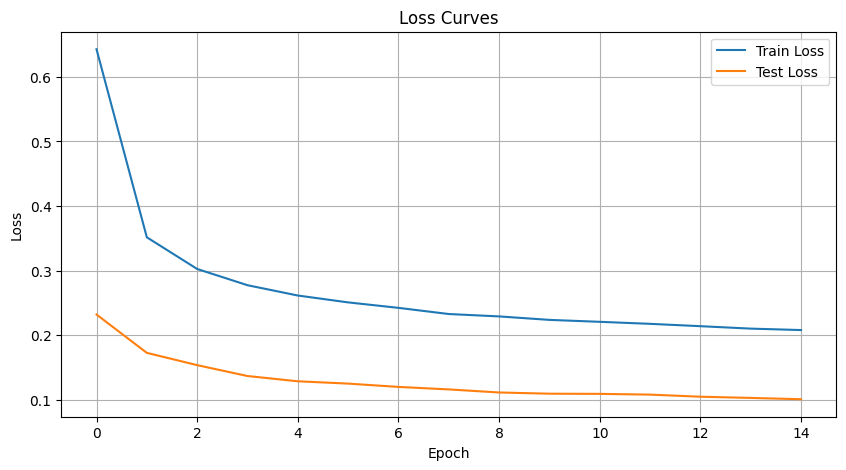

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curves")

plt.legend()
plt.grid()
plt.show()

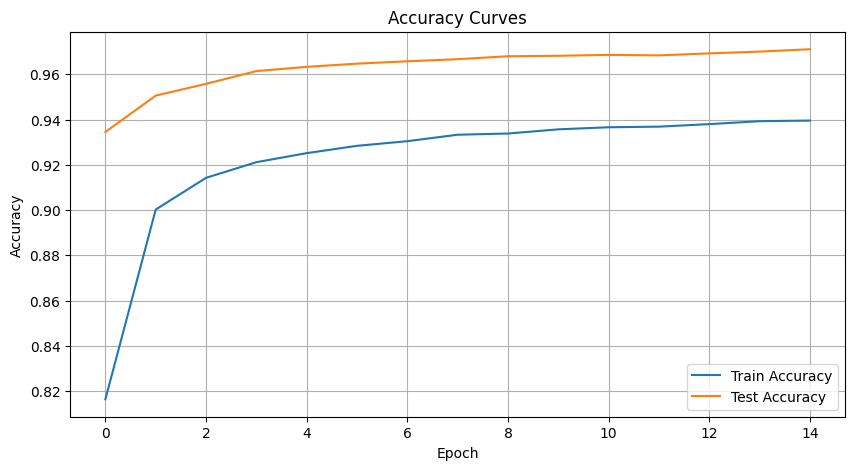

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy Curves")

plt.legend()
plt.grid()
plt.show()

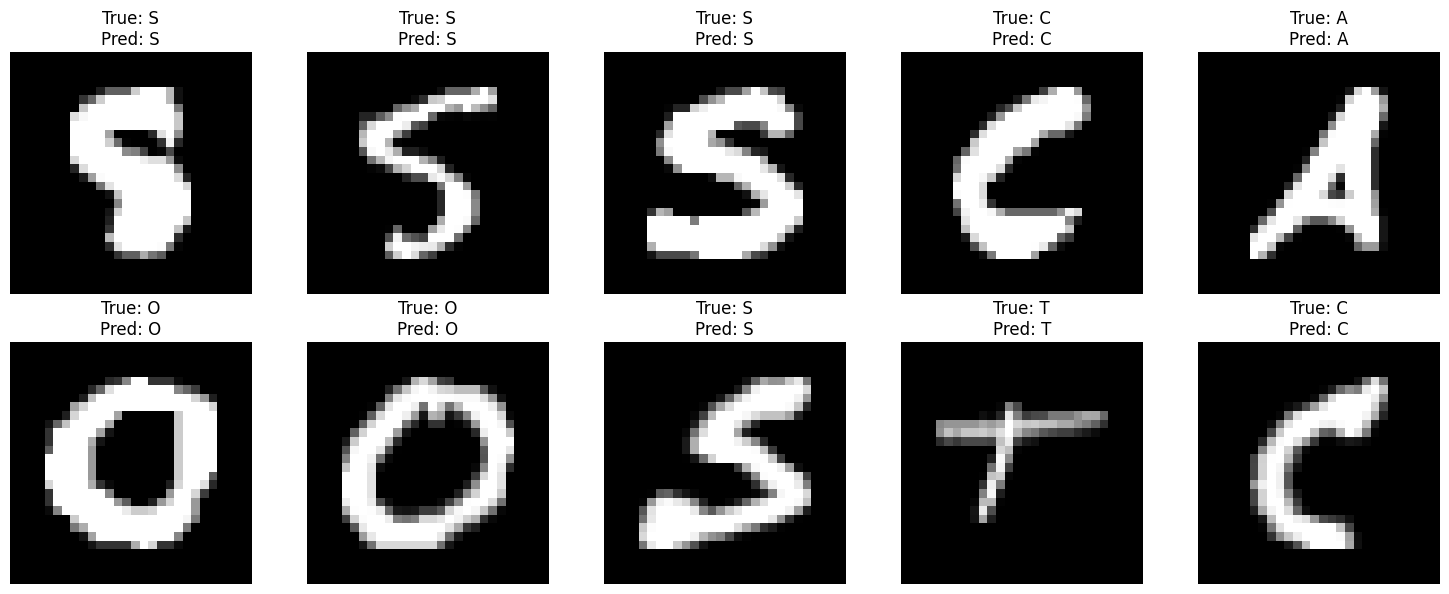

In [13]:
letters = [chr(i) for i in range(ord('A'), ord('A') + num_classes)]

indices = np.random.choice(len(test_dataset), 10, replace=False)

plt.figure(figsize=(15, 6))

model.eval()

for i, idx in enumerate(indices):

    image, label = test_dataset[idx]

    with torch.no_grad():

        output = model(image.to(device).unsqueeze(0))

        prediction = torch.argmax(output, dim=1).item()

    image_2d = image.view(28, 28).numpy()

    plt.subplot(2, 5, i + 1)

    plt.imshow(image_2d, cmap="gray")

    true_letter = letters[label]
    predicted_letter = letters[prediction]

    plt.title(f"True: {true_letter}\nPred: {predicted_letter}")

    plt.axis("off")

plt.tight_layout()

plt.show()